# 06 - Preparação para modelagem e primeira avaliação
Este notebook reúne a etapa mais completa do fluxo: preparação da base, separação entre treino e teste, padronização das variáveis, treinamento do primeiro modelo e avaliação inicial.

Ao final desta etapa, já temos uma primeira linha de base com **Regressão Logística**, que servirá como referência para comparar outros algoritmos depois.

In [35]:
import pandas as pd

# Carregar a base já limpa e com a variável alvo codificada.
df = pd.read_csv('../data/breast-cancer-wisconsin-data-clean.csv')


# Separar variável alvo (y): o diagnóstico que o modelo precisa prever.
y = df['diagnostico']

# Separar variáveis de entrada (X): características usadas no treinamento.
X = df.drop(columns=['diagnostico'])

# Conferir o tamanho das matrizes após a preparação da base.
print(X.shape)
print(y.shape)
print('Quantidade de colunas usadas no modelo:', len(X.columns))

(569, 30)
(569,)
Quantidade de colunas usadas no modelo: 30


### Separação dos dados

Aqui vamos realizar a separação dos dados em partes de treino e teste.


In [36]:
# Separar os dados entre treino e teste.
# Aqui usamos 80% para treinar o modelo e 20% para avaliar
# seu desempenho em dados que ele ainda não viu.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Validar o tamanho dos conjuntos gerados após a separação.
# Esses valores ajudam a confirmar se a divisão treino/teste foi aplicada corretamente.
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


### Padrinização das variáveis

Como temos informações com valores alto e com valores baixos, e também para evitar o out bound, ou seja, valores que são extremamente alto ou baixo. Vaoms padronizar os valores.

In [37]:
# Padronizar as variáveis numéricas com StandardScaler.
# O scaler aprende média e desvio padrão no conjunto de treino
# e aplica a mesma transformação no teste para evitar vazamento de dados.
from sklearn.preprocessing import StandardScaler

#cria o objeto
scaler = StandardScaler()

# Ajustar e transformar treino
#calcula a meia e o desvio de cada coluna, exemplo:
# raio_media:
# média = 14.10
# desvio padrão = 3.52
# E ja transforma o treino

#realizo a media com base na massa de dados de treino
scaler.fit(X_train)

#transformo os dados
X_train_scaled = scaler.transform(X_train)

# após isto teremos valores próximos de 1, ou seja 0 a 2
#para modelos como KNN eregrassão logistica, que dependem de distancia

# Transformar teste com os parâmetros aprendidos no treino
X_test_scaled = scaler.transform(X_test)

# Conferir o efeito da padronização nas variáveis de treino.
# Depois do StandardScaler, esperamos médias próximas de zero
# e desvios padrão próximos de um.
colunas = X_train.columns

# Antes da padronização
df_before = pd.DataFrame(X_train, columns=colunas)

# Depois da padronização
df_after = pd.DataFrame(X_train_scaled, columns=colunas)

resumo_validacao = pd.DataFrame({
    'media_antes': df_before.mean(),
    'desvio_pop_antes': df_before.std(ddof=0),
    'desvio_amostral_antes': df_before.std(ddof=1),
    'media_apos': df_after.mean(),
    'desvio_pop_apos': df_after.std(ddof=0),
    'desvio_amostral_apos': df_after.std(ddof=1)
})

print('=== ANTES DA NORMALIZAÇÃO ===')
print('Maior |média| antes:', resumo_validacao['media_antes'].abs().max())
print('Maior desvio populacional antes:', resumo_validacao['desvio_pop_antes'].max())
print('Maior desvio amostral antes:', resumo_validacao['desvio_amostral_antes'].max())

print('\n=== APÓS A NORMALIZAÇÃO ===')
print('Maior |média| após normalização:', resumo_validacao['media_apos'].abs().max())
print('Maior |desvio populacional - 1|:', (resumo_validacao['desvio_pop_apos'] - 1).abs().max())
print('Maior |desvio amostral - 1|:', (resumo_validacao['desvio_amostral_apos'] - 1).abs().max())

print('\nPrimeiras colunas validadas:')
print(resumo_validacao.head())

=== ANTES DA NORMALIZAÇÃO ===
Maior |média| antes: 876.9870329670329
Maior desvio populacional antes: 567.0486811155926
Maior desvio amostral antes: 567.672840557284

=== APÓS A NORMALIZAÇÃO ===
Maior |média| após normalização: 6.754060070686666e-16
Maior |desvio populacional - 1|: 2.220446049250313e-16
Maior |desvio amostral - 1|: 0.0011007157982689808

Primeiras colunas validadas:
                 media_antes  desvio_pop_antes  desvio_amostral_antes  \
raio_media         14.117635          3.531928               3.535815   
textura_media      19.185033          4.261314               4.266005   
perimetro_media    91.882242         24.295284              24.322027   
area_media        654.377582        354.552925             354.943187   
suavidade_media     0.095744          0.013908               0.013923   

                   media_apos  desvio_pop_apos  desvio_amostral_apos  
raio_media      -3.162306e-16              1.0              1.001101  
textura_media   -3.513673e-17    

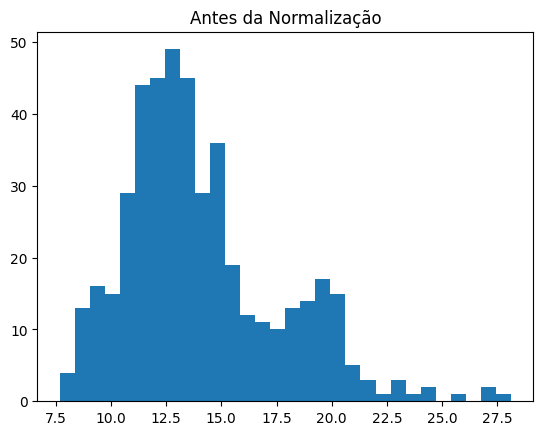

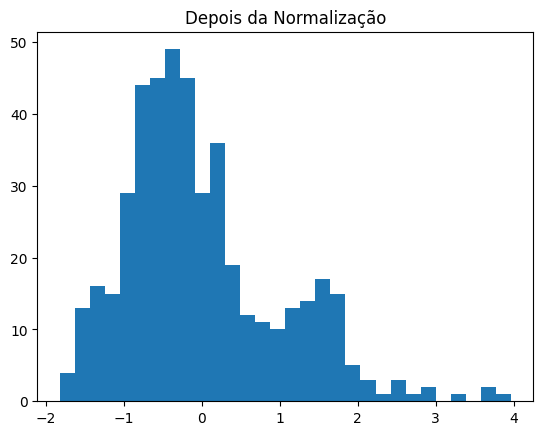

In [38]:
# Visualizar o efeito da padronização em uma variável de exemplo.
# O formato da distribuição tende a ser preservado, mas a escala muda.
import matplotlib.pyplot as plt

coluna = colunas[0]  # exemplo de feature para comparar antes e depois

plt.figure()
plt.hist(df_before[coluna], bins=30)
plt.title('Antes da Normalização')
plt.show()

plt.figure()
plt.hist(df_after[coluna], bins=30)
plt.title('Depois da Normalização')
plt.show()

### Observação sobre a normalização
As próximas células continuam analisando os dados já padronizados.

A normalização principal já foi feita acima; daqui em diante o foco é **inspecionar os resultados da transformação** e comparar os valores antes e depois.

In [39]:
# Converter a matriz padronizada em DataFrame para facilitar a inspeção.
# Assim recuperamos os nomes das colunas e podemos visualizar os primeiros valores.
import pandas as pd

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_train_scaled_df.head()

,raio_media,textura_media,perimetro_media,area_media,suavidade_media,compactacao_media,concavidade_media,pontos_concavos_media,simetria_media,dimensao_fractal_media,...,raio_pior,textura_pior,perimetro_pior,area_pior,suavidade_pior,compactacao_pior,concavidade_pior,pontos_concavos_pior,simetria_pior,dimensao_fractal_pior
0,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173,...,-1.232861,-0.476309,-1.247920,-0.973968,0.722894,1.186732,4.672828,0.932012,2.097242,1.886450
1,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396,...,2.173314,1.311279,2.081617,2.137405,0.761928,3.265601,1.928621,2.698947,1.891161,2.497838
2,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379,...,-1.295284,-1.040811,-1.245220,-0.999715,-1.438693,-0.548564,-0.644911,-0.970239,0.597602,0.057894
3,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041,...,-0.829197,1.593530,-0.873572,-0.742947,0.796624,-0.729392,-0.774950,-0.809483,0.798928,-0.134497
4,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213,...,-1.085129,-1.334616,-1.117138,-0.896549,-0.174876,-0.995079,-1.209146,-1.354582,1.033544,-0.205732


In [40]:
# Gerar estatísticas descritivas dos dados já padronizados.
# Aqui esperamos observar médias próximas de zero e dispersões controladas.
X_train_scaled_df.describe()

,raio_media,textura_media,perimetro_media,area_media,suavidade_media,compactacao_media,concavidade_media,pontos_concavos_media,simetria_media,dimensao_fractal_media,...,raio_pior,textura_pior,perimetro_pior,area_pior,suavidade_pior,compactacao_pior,concavidade_pior,pontos_concavos_pior,simetria_pior,dimensao_fractal_pior
count,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,...,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02
mean,-3.162306e-16,-3.513673e-17,-1.132183e-16,3.669836e-16,-2.381489e-16,-4.294489e-17,-5.953723e-17,2.225326e-16,1.444510e-16,5.055785e-16,...,-7.027346e-17,-6.754060e-16,-2.928061e-17,1.815398e-16,-1.561632e-17,-2.249727e-16,-7.612958e-17,-8.198570e-17,5.153387e-16,2.147245e-17
std,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,...,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00,1.001101e+00
min,-1.819583e+00,-2.223500e+00,-1.809497e+00,-1.365036e+00,-3.100011e+00,-1.607228e+00,-1.119899e+00,-1.269910e+00,-2.345430e+00,-1.776889e+00,...,-1.572438e+00,-2.230887e+00,-1.578174e+00,-1.152259e+00,-2.617938e+00,-1.455995e+00,-1.312795e+00,-1.749805e+00,-2.124261e+00,-1.616973e+00
25%,-6.830930e-01,-7.075360e-01,-6.907613e-01,-6.602049e-01,-7.132037e-01,-7.770872e-01,-7.505387e-01,-7.349048e-01,-7.010461e-01,-7.097920e-01,...,-6.616975e-01,-7.412292e-01,-6.853483e-01,-6.358132e-01,-7.430298e-01,-6.961323e-01,-7.555873e-01,-7.700987e-01,-6.499846e-01,-7.189616e-01
50%,-2.314983e-01,-1.185158e-01,-2.429378e-01,-2.895973e-01,-8.082013e-02,-2.413402e-01,-3.446456e-01,-3.911235e-01,-6.915087e-02,-1.772851e-01,...,-2.632354e-01,-5.210786e-02,-2.829543e-01,-3.357508e-01,-2.741590e-02,-2.753858e-01,-2.304110e-01,-2.386392e-01,-1.236838e-01,-2.135847e-01
75%,4.593426e-01,5.631988e-01,4.884799e-01,3.193386e-01,6.331729e-01,5.281282e-01,5.473870e-01,6.737569e-01,5.354290e-01,4.642225e-01,...,4.525400e-01,6.857059e-01,5.263332e-01,2.724862e-01,6.296478e-01,5.738568e-01,5.383496e-01,7.189995e-01,4.319440e-01,4.600643e-01
max,3.961679e+00,4.715674e+00,3.976811e+00,5.208312e+00,4.864642e+00,3.964311e+00,4.256736e+00,4.022271e+00,4.476124e+00,4.815921e+00,...,4.120889e+00,3.962127e+00,4.322305e+00,5.955420e+00,3.767506e+00,4.424833e+00,4.672828e+00,2.709674e+00,5.917679e+00,4.999482e+00


In [41]:
print("Antes da normalização:")
print(X_train.iloc[0])

print("\nDepois da normalização:")
print(X_train_scaled_df.iloc[0])

Antes da normalização:
raio_media                        9.029000
textura_media                    17.330000
perimetro_media                  58.790000
area_media                      250.500000
suavidade_media                   0.106600
compactacao_media                 0.141300
concavidade_media                 0.313000
pontos_concavos_media             0.043750
simetria_media                    0.211100
dimensao_fractal_media            0.080460
raio_erro_padrao                  0.327400
textura_erro_padrao               1.194000
perimetro_erro_padrao             1.885000
area_erro_padrao                 17.670000
suavidade_erro_padrao             0.009549
compactacao_erro_padrao           0.086060
concavidade_erro_padrao           0.303800
pontos_concavos_erro_padrao       0.033220
simetria_erro_padrao              0.041970
dimensao_fractal_erro_padrao      0.009559
raio_pior                        10.310000
textura_pior                     22.650000
perimetro_pior                 

## Treinar o primeiro modelo de classificação: Regressão Logística

In [42]:
# Neste problema, 0 representa benigno e 1 representa maligno.
from sklearn.linear_model import LogisticRegression

# Criar o modelo base para servir como referência inicial.
model = LogisticRegression(max_iter=1000)

# Ajustar o modelo aos dados de treino já padronizados.
model.fit(X_train_scaled, y_train)

# Gerar previsões para o conjunto de teste.
# Essas previsões serão comparadas com os valores reais para medir o desempenho do modelo.
y_pred = model.predict(X_test_scaled)


# Calcular a acurácia do modelo.
# A acurácia mostra a proporção total de acertos,
# mas sozinha não é suficiente em contexto médico.
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.4f}")

# Exibir precision, recall e F1-score por classe.
# Em saúde, o recall da classe positiva costuma ser especialmente importante,
# pois errar um caso doente pode ter alto custo clínico.
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

Acurácia: 0.9737
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



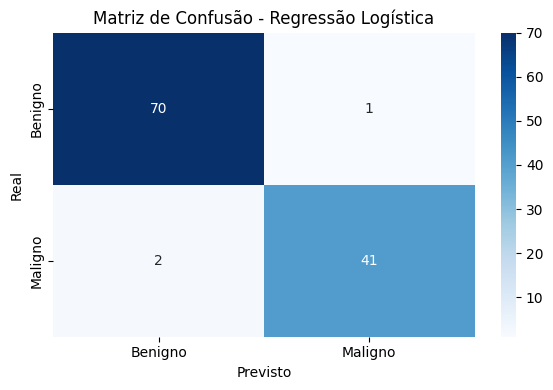

In [43]:
# Gerar o gráfico da matriz de confusão da Regressão Logística.
# Esta célula deve ser executada após a célula de treinamento do modelo logístico.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Recalcular as previsões com o modelo logístico para garantir que a matriz use este modelo.
y_pred_logistica = model.predict(X_test_scaled)

# Calcular a matriz de confusão comparando valores reais e previstos.
cm_logistica = confusion_matrix(y_test, y_pred_logistica)

# Exibir a matriz de confusão em formato de mapa de calor.
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_logistica,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benigno', 'Maligno'],
    yticklabels=['Benigno', 'Maligno']
 )
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.tight_layout()
plt.show()

## Treinar o modelo com Árvore de Decisão

Utilizamos o modelo de Árvore de Decisão, que realiza classificações baseadas em regras sequenciais.

Acurácia (Árvore): 0.9474
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



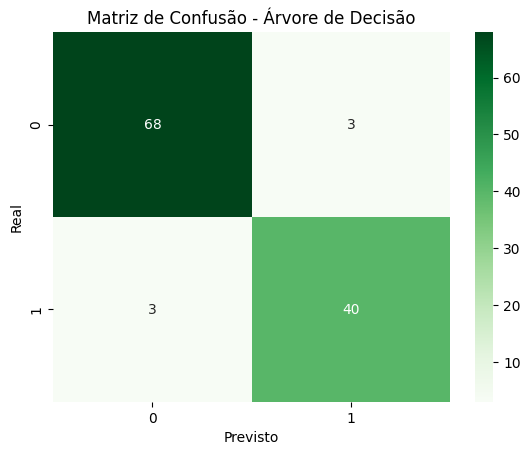

In [44]:
from sklearn.tree import DecisionTreeClassifier

# Criar modelo
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Treinar
tree_model.fit(X_train_scaled, y_train)

#Previsões

y_pred_tree = tree_model.predict(X_test_scaled)

#Avaliação
from sklearn.metrics import accuracy_score

accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Acurácia (Árvore): {accuracy_tree:.4f}")

#Relatório
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tree))

#Matriz de Confusão
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_tree = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()



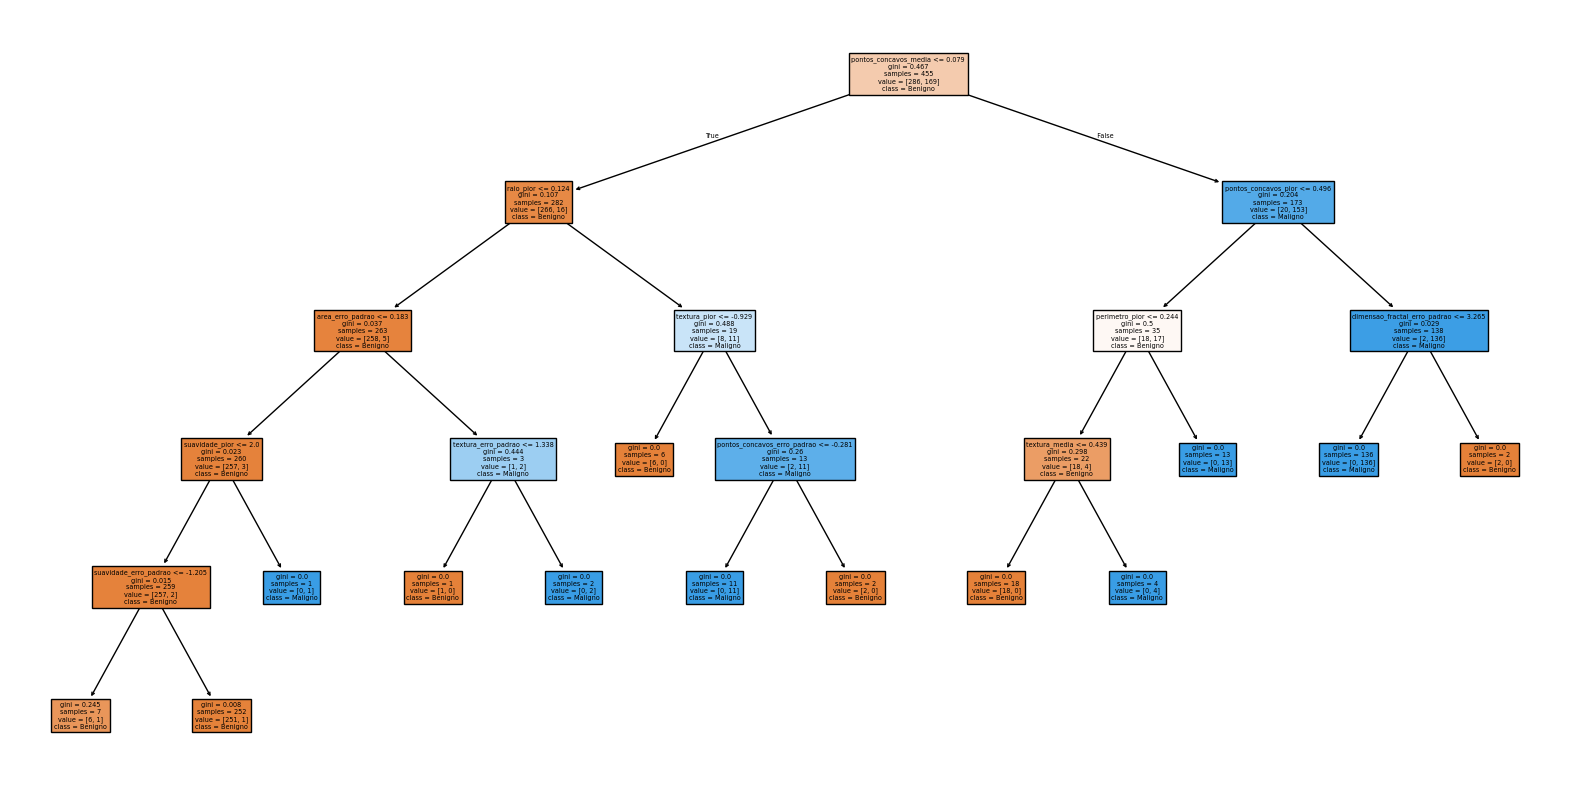

In [45]:
#Visualizar Árvore
#A árvore de decisão permite interpretar claramente as regras utilizadas pelo modelo, 
# evidenciando quais variáveis são mais relevantes na classificação
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree_model, filled=True, feature_names=X.columns, class_names=['Benigno', 'Maligno'])
plt.show()

## Treinar o modelo com KNN

Modelo baseado em distâncias



In [46]:
from sklearn.neighbors import KNeighborsClassifier

# Criar modelo
knn_model = KNeighborsClassifier(n_neighbors=5) # n_neighbors (numero de vizinhos)

# Treinar
knn_model.fit(X_train_scaled, y_train)

#fazer previsão
y_pred_knn = knn_model.predict(X_test_scaled)

#avaliação
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Acurácia (KNN): {accuracy_knn:.4f}")



Acurácia (KNN): 0.9474


In [47]:
#relatório
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



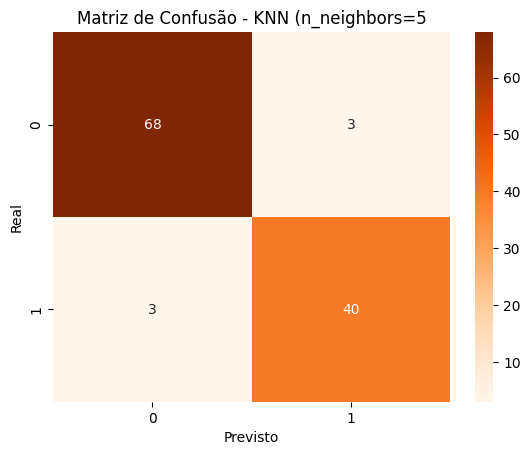

In [48]:
#matriza de confusão
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - KNN (n_neighbors=5')
plt.show()

In [49]:
#Testar diferentes valores de K

for k in [3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"K={k} → Acurácia: {acc:.4f}")

K=3 → Acurácia: 0.9474
K=5 → Acurácia: 0.9474
K=7 → Acurácia: 0.9474
K=9 → Acurácia: 0.9649


In [50]:
from sklearn.neighbors import KNeighborsClassifier

# Criar modelo (agora com 9 vizinhos)
knn_model = KNeighborsClassifier(n_neighbors=9) # n_neighbors (numero de vizinhos)

# Treinar
knn_model.fit(X_train_scaled, y_train)

#fazer previsão
y_pred_knn = knn_model.predict(X_test_scaled)

#avaliação
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Acurácia (KNN): {accuracy_knn:.4f}")



Acurácia (KNN): 0.9649


In [51]:
#relatório
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



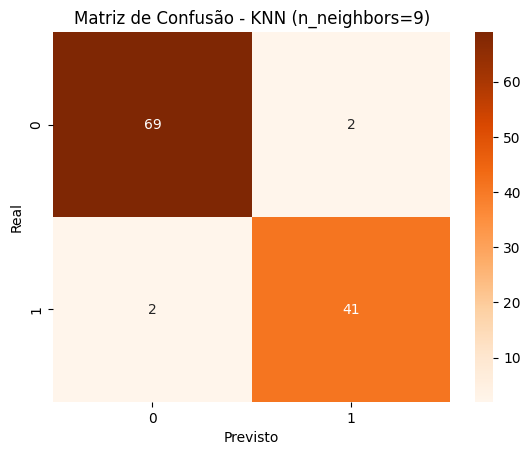

In [52]:
#matriza de confusão
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - KNN (n_neighbors=9)')
plt.show()

### Avaliação de Resultado

Melhor?
Pior?
Mais erro em maligno?

| Modelo    | Accuracy | Recall |
| --------- | -------- | ------ |
| Logística | ...      | ...    |
| Árvore    | ...      | ...    |
| KNN       | ...      | ...    |


Preparamos a base com 569 registros e 30 variáveis, 455 para treino e 114 para teste, aplicamos StandardScaler, Regressão Logística, Árvore de Decisão e KNN. 

### A Regressão Logística
- A Regressão Logística ficou como melhor resultado inicial, com acurácia 0.9737, recall da classe 1 igual a 0.95 e F1-score da classe 1 igual a 0.96. 
- A Árvore e o KNN ficaram abaixo, ambos com acurácia 0.9474 e recall da classe 1 igual a 0.9

- A Regressão Logística acertou muito bem os casos malignos. Como o recall da classe 1 foi 0.95, isso significa que ela conseguiu identificar aproximadamente 95% dos casos malignos reais. Ou seja, de um total de 43  casos, se aplicar 5%, dois casos não seriam identificados.

Ou seja, acertamos 41 Maligno e deixamos passar 2. Falso Negativo, mas um grande risco no contexto médico. 
Para contexto medido o ideal seria melhor identificar falso positivo, não gerando risco ao paciente.

### Árvore de Decisão

Acurácia: 0.9474

Classe 1:
precision = 0.93
recall    = 0.93
f1-score  = 0.93

- A matriz de confusão da árvore foi:
              Previsto 0    Previsto 1
Real 0             68            3
Real 1              3           40


A árvore acertou:

68 benignos corretamente
40 malignos corretamente

Mas errou:

3 benignos classificados como malignos ou vice e versa


### KNN

O KNN com k=5 teve praticamente o mesmo comportamento da árvore:

Acurácia: 0.9474

Classe 1:
precision = 0.93
recall    = 0.93
f1-score  = 0.93

- Matriz de confusão:
  
              Previsto 0    Previsto 1
Real 0             68            3
Real 1              3           40

- Valores diferente de k:
  
K=3 → Acurácia: 0.9474
K=5 → Acurácia: 0.9474
K=7 → Acurácia: 0.9474
K=9 → Acurácia: 0.9649

Isso mostra que o KNN melhora quando usa k=9. Então faz sentido incluir o GridSearchCV para encontrar o melhor valor automaticamente.

